In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../datasets/placement_cse.csv')

In [3]:
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   cgpa                  1000 non-null   float64
 1   placement_exam_marks  1000 non-null   float64
 2   placed                1000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 23.6 KB


In [5]:
df.describe()

,cgpa,placement_exam_marks,placed
count,1000.000000,1000.000000,1000.000000
mean,6.961240,32.225000,0.489000
std,0.615898,19.130822,0.500129
min,4.890000,0.000000,0.000000
25%,6.550000,17.000000,0.000000
50%,6.960000,28.000000,0.000000
75%,7.370000,44.000000,1.000000
max,9.120000,100.000000,1.000000


C:\Users\manoj\AppData\Local\Temp\ipykernel_48788\3792736820.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['cgpa'])
C:\Users\manoj\AppData\Local\Temp\ipykernel_48788\3792736820.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['placement_exam_marks'])


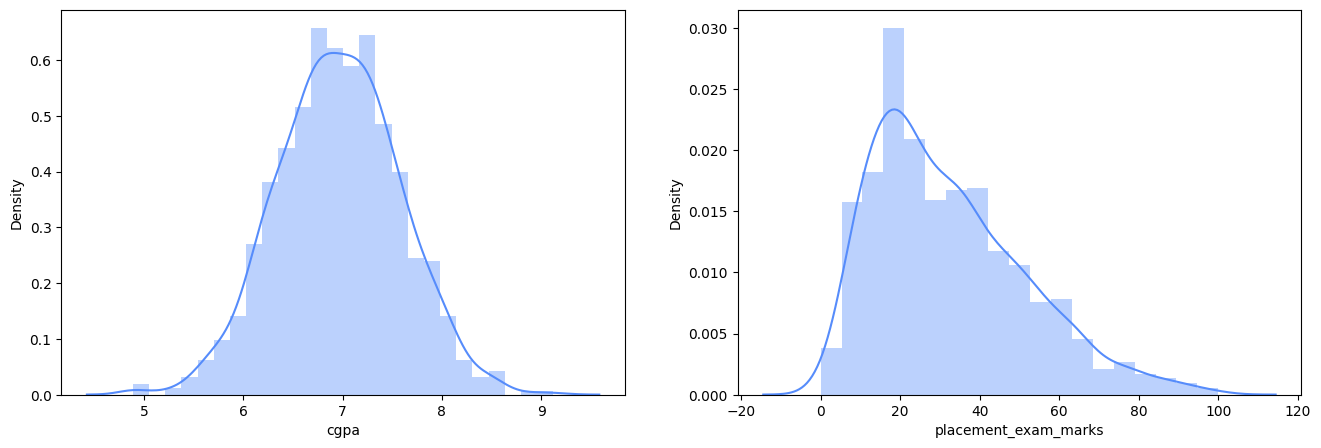

In [6]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.distplot(df['cgpa'])

plt.subplot(1,2,2)
sns.distplot(df['placement_exam_marks'])

plt.show()

In [7]:
df['placement_exam_marks'].skew()

0.8356419499466834

In [24]:
df['placement_exam_marks'].describe()

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

<Axes: ylabel='placement_exam_marks'>

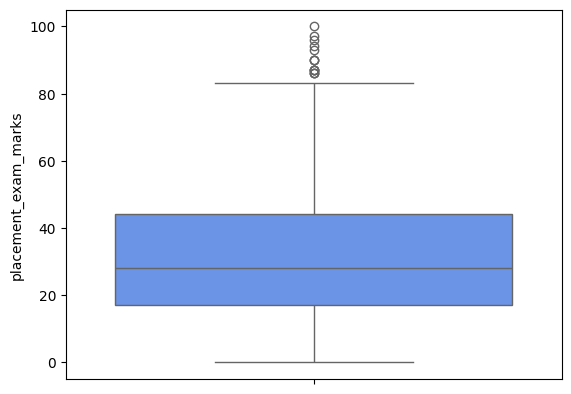

In [31]:
sns.boxplot(df['placement_exam_marks'])

In [ ]:
# Finding the boundary values
Q1 = df['placement_exam_marks'].quantile(0.25)
Q3 = df['placement_exam_marks'].quantile(0.75)
IQR = Q3 - Q1

In [27]:
IQR

27.0

In [30]:
print("Highest allowed", Q3 + 1.5*IQR)
print("Lowest allowed", Q1 - 1.5*IQR)

Highest allowed 84.5
Lowest allowed -23.5


In [33]:
# Finding the outliers
outliers = df[(df['placement_exam_marks'] > Q3 + 1.5*IQR) | (df['placement_exam_marks'] < Q1 - 1.5*IQR)]
outliers, outliers.shape

(     cgpa  placement_exam_marks  placed  cgpa_zscore
 9    7.75                  94.0       1     1.280667
 40   6.60                  86.0       1    -0.586526
 61   7.51                  86.0       0     0.890992
 134  6.33                  93.0       0    -1.024910
 162  7.80                  90.0       0     1.361849
 283  7.09                  87.0       0     0.209061
 290  8.38                  87.0       0     2.303564
 311  6.97                  87.0       1     0.014223
 324  6.64                  90.0       0    -0.521580
 630  6.56                  96.0       1    -0.651472
 685  6.05                  87.0       1    -1.479531
 730  6.14                  90.0       1    -1.333403
 771  7.31                  86.0       1     0.566263
 846  6.99                  97.0       0     0.046696
 917  5.95                 100.0       0    -1.641896,
 (15, 4))

Trimming

In [34]:
df_no_outliers = df[(df['placement_exam_marks'] <= Q3 + 1.5*IQR) & (df['placement_exam_marks'] >= Q1 - 1.5*IQR)]
df_no_outliers, df_no_outliers.shape

(     cgpa  placement_exam_marks  placed  cgpa_zscore
 0    7.19                  26.0       1     0.371425
 1    7.46                  38.0       1     0.809810
 2    7.54                  40.0       1     0.939701
 3    6.42                   8.0       1    -0.878782
 4    7.23                  17.0       0     0.436371
 ..    ...                   ...     ...          ...
 995  8.87                  44.0       1     3.099150
 996  9.12                  65.0       1     3.505062
 997  4.89                  34.0       0    -3.362960
 998  8.62                  46.0       1     2.693239
 999  4.90                  10.0       1    -3.346724
 
 [985 rows x 4 columns],
 (985, 4))

C:\Users\manoj\AppData\Local\Temp\ipykernel_48788\1079060974.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['placement_exam_marks'])
C:\Users\manoj\AppData\Local\Temp\ipykernel_48788\1079060974.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_no_outliers['placement_exam_marks'])


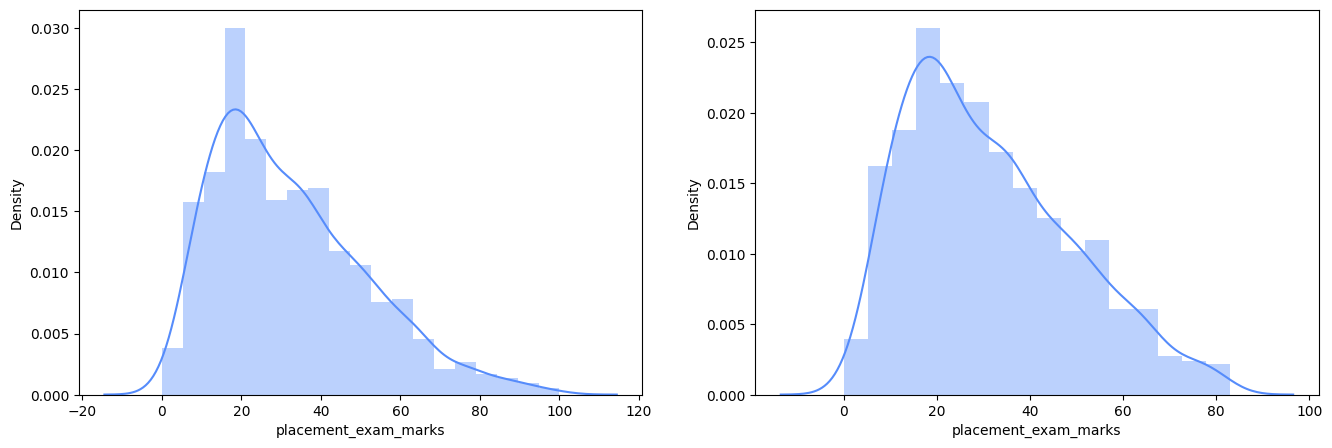

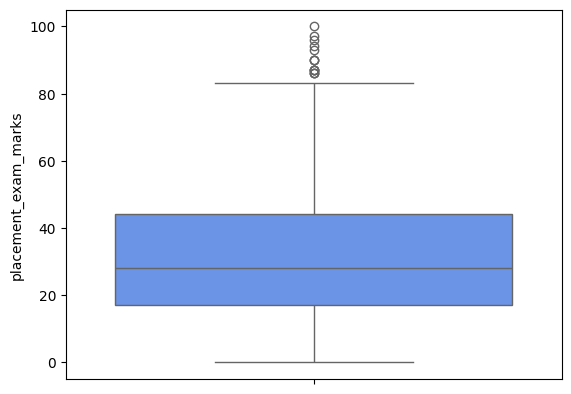

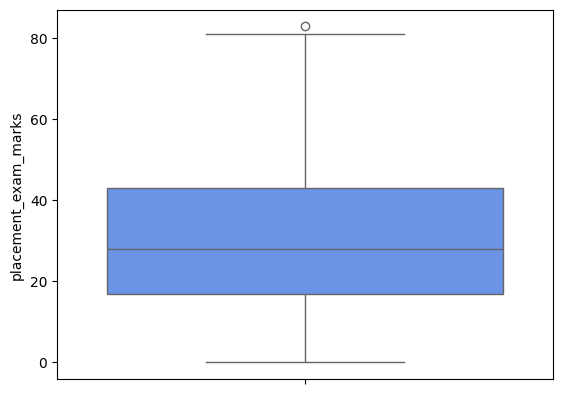

In [41]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.distplot(df['placement_exam_marks'])
plt.subplot(1,2,2)
sns.distplot(df_no_outliers['placement_exam_marks'])
plt.show()
sns.boxplot(df['placement_exam_marks'])
plt.show()
sns.boxplot(df_no_outliers['placement_exam_marks'])
plt.show()


Capping

In [42]:
# Capping the outliers
df_capped = df.copy()
df_capped['placement_exam_marks'] = np.where(df_capped['placement_exam_marks'] > Q3 + 1.5*IQR, Q3 + 1.5*IQR, df_capped['placement_exam_marks'])
df_capped['placement_exam_marks'] = np.where(df_capped['placement_exam_marks'] < Q1 - 1.5*IQR, Q1 - 1.5*IQR, df_capped['placement_exam_marks'])


In [45]:
df.describe()

,cgpa,placement_exam_marks,placed,cgpa_zscore
count,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,6.961240,32.225000,0.489000,-1.465494e-16
std,0.615898,19.130822,0.500129,1.000000e+00
min,4.890000,0.000000,0.000000,-3.362960e+00
25%,6.550000,17.000000,0.000000,-6.677081e-01
50%,6.960000,28.000000,0.000000,-2.013321e-03
75%,7.370000,44.000000,1.000000,6.636815e-01
max,9.120000,100.000000,1.000000,3.505062e+00


In [44]:
df_capped.describe()

,cgpa,placement_exam_marks,placed,cgpa_zscore
count,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,6.961240,32.136500,0.489000,-1.465494e-16
std,0.615898,18.865419,0.500129,1.000000e+00
min,4.890000,0.000000,0.000000,-3.362960e+00
25%,6.550000,17.000000,0.000000,-6.677081e-01
50%,6.960000,28.000000,0.000000,-2.013321e-03
75%,7.370000,44.000000,1.000000,6.636815e-01
max,9.120000,84.500000,1.000000,3.505062e+00


C:\Users\manoj\AppData\Local\Temp\ipykernel_48788\1191496507.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['placement_exam_marks'])
C:\Users\manoj\AppData\Local\Temp\ipykernel_48788\1191496507.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_capped['placement_exam_marks'])


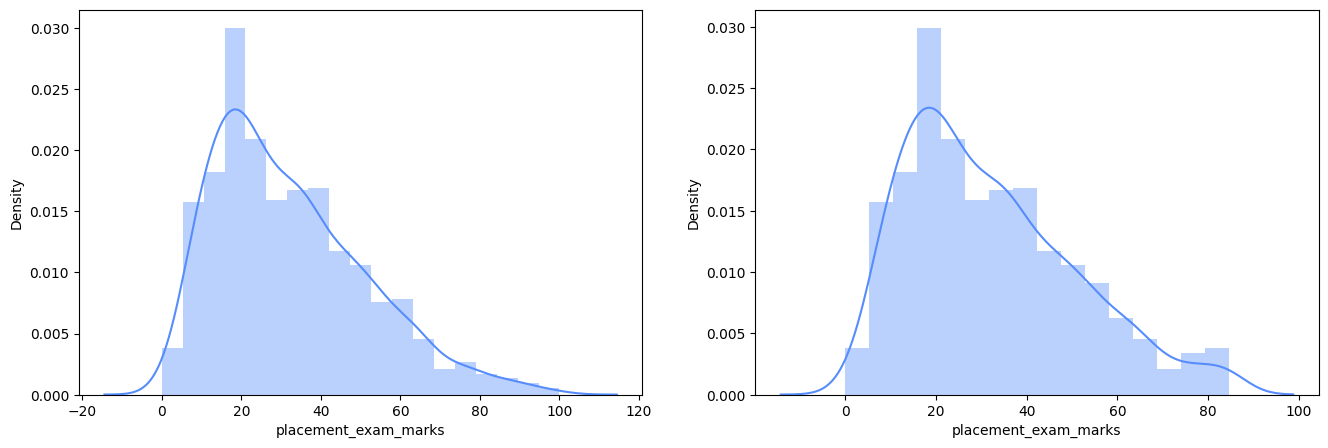

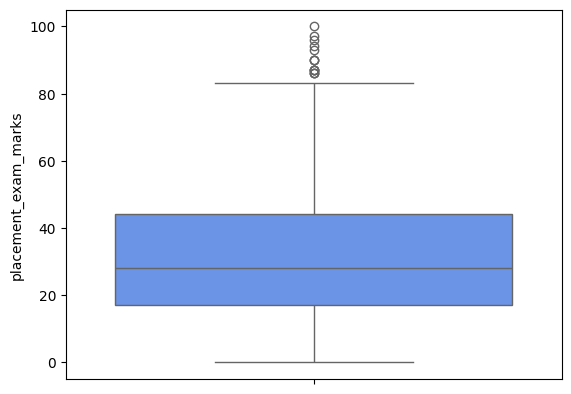

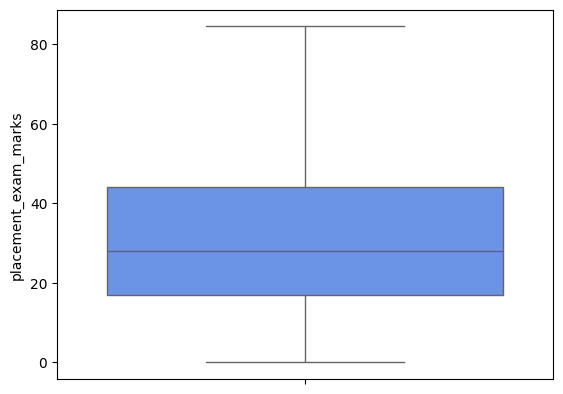

In [46]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.distplot(df['placement_exam_marks'])
plt.subplot(1,2,2)
sns.distplot(df_capped['placement_exam_marks'])
plt.show()
sns.boxplot(df['placement_exam_marks'])
plt.show()
sns.boxplot(df_capped['placement_exam_marks'])
plt.show()